<a href="https://colab.research.google.com/github/chiaratomaiuolo/Data_Mining_project/blob/main/LSTM_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tutorial on LSTM
We try to build a LSTM that find the maximum in a sequence of numbers and returns its value and position

## Import useful stuff

In [ ]:
from keras.layers import Input,Dense,LSTM,BatchNormalization
from keras.models import Model
import numpy as np
from math import *
from matplotlib import pyplot as plt


## Lets generate some data

We now generate ourself some images with a circle or a rectangle, of random color, in a random position.

Three different modes of generating the images are implemented:

*   A single shape per figure
*   Multiple shapes mixed in each figure
*   A single figure keeping track of the "bounding box"



### Additional Exercise
1. Try adding some random noise in the image background
2. Try adding more classes such e.g. Lines or Ellipses


In [ ]:


nsamples=20000
maxlen=100

data=np.zeros((nsamples,maxlen,2))
maxima=np.zeros(nsamples)
maximaIdx=np.zeros(nsamples)

for i in range(nsamples) :
  l=int(np.random.rand()*maxlen)+1
  seq=np.random.rand(l,2)
  pad=np.zeros((maxlen-l,2))
  row=np.concatenate((seq,pad))
  mod=[(x[0]**2+x[1]**2)**0.5 for x in row]
  maxima[i]=np.max(mod)
  maximaIdx[i]=np.argmax(mod)
  data[i,:]=row

targets=np.stack((maxima,maximaIdx),axis=-1)

print(data)

print(targets)

[[[0.17465575 0.36785944]
  [0.77830871 0.34997788]
  [0.35373472 0.03312997]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.42823307 0.05886131]
  [0.90810299 0.39967933]
  [0.05021387 0.26970973]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.191075   0.50710318]
  [0.43386243 0.0541295 ]
  [0.23602456 0.95128715]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 ...

 [[0.91163065 0.05733115]
  [0.22108091 0.25791535]
  [0.24992329 0.09884365]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.03154968 0.0837027 ]
  [0.50265804 0.71363482]
  [0.1282083  0.64594216]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.24421851 0.58157708]
  [0.65150995 0.55464284]
  [0.28111746 0.48782193]
  ...
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]]]
[[ 1.31148

In [ ]:
inputs=Input(shape=(maxlen,2,))
norm=BatchNormalization()(inputs)
hidden=  LSTM(80)(norm)
#hidden=  LSTM(20, activation='relu')(inputs)
hidden=  Dense(30, activation='relu')(hidden)
hidden=  Dense(20, activation='relu')(hidden)
outputs=  Dense(2, activation='relu')(hidden)
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss="MSE", optimizer='adam')

model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 100, 2)]          0         
                                                                 
 batch_normalization_3 (Batc  (None, 100, 2)           8         
 hNormalization)                                                 
                                                                 
 lstm_3 (LSTM)               (None, 80)                26560     
                                                                 
 dense_9 (Dense)             (None, 30)                2430      
                                                                 
 dense_10 (Dense)            (None, 20)                620       
                                                                 
 dense_11 (Dense)            (None, 2)                 42        
                                                           

And now let's fit it to our data.
The sample is automatically split in two so that 50% of it is used for validation and the other half for training


In [ ]:
print(targets)
history=model.fit(data,targets,validation_split=0.5,epochs=20)

[[ 1.31148021 43.        ]
 [ 1.08774727  4.        ]
 [ 1.21446286 11.        ]
 ...
 [ 1.2569434  13.        ]
 [ 1.28904925 16.        ]
 [ 1.36133262 26.        ]]
Epoch 1/20
313/313 [==============================] - 13s 33ms/step - loss: 272.9337 - val_loss: 245.1943
Epoch 2/20
313/313 [==============================] - 10s 31ms/step - loss: 246.7605 - val_loss: 288.6916
Epoch 3/20
313/313 [==============================] - 10s 31ms/step - loss: 155.7558 - val_loss: 143.9214
Epoch 4/20
313/313 [==============================] - 10s 31ms/step - loss: 141.6095 - val_loss: 147.7683
Epoch 5/20
313/313 [==============================] - 10s 31ms/step - loss: 140.3232 - val_loss: 141.0075
Epoch 6/20
313/313 [==============================] - 10s 31ms/step - loss: 140.3246 - val_loss: 139.6808
Epoch 7/20
313/313 [==============================] - 10s 31ms/step - loss: 139.6317 - val_loss: 139.6147
Epoch 8/20
313/313 [==============================] - 10s 31ms/step - loss: 137.0661 - val

*history* contains information about the training.  We can now now show the loss vs epoch for both validation and training samples.




dict_keys(['loss', 'val_loss'])


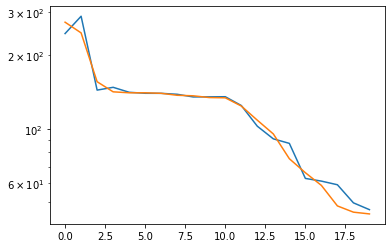

In [ ]:
print(history.history.keys())
plt.plot(history.history["val_loss"])
plt.plot(history.history["loss"])
plt.yscale('log')
plt.show()
#plt.plot(history.history["val_accuracy"])
#plt.plot(history.history["accuracy"])
#plt.show()


In [ ]:
print(model.predict(np.expand_dims(np.array([[0,0],[0,1],[1,1],[0,0],[0,0]]),axis=0) ))

#print(data[0:1])
#print(model.predict(data[0:1]))
#print(targets[0])

ValueError: ignored

Let's try to mix an image with circles and rectangles and see how the network would evaluate it

The following code can be used to visualize what features the first conv layer is looking at